Dispositivo disponible: cuda
GPU utilizada: Tesla T4


Saving dataset_compliance_risk.csv to dataset_compliance_risk (4).csv
Primeros registros del dataset:


,text,label
0,The product label is missing the allergen decl...,risk
1,Nutrition facts are complete and aligned with ...,no_risk
2,The ingredient list includes a restricted addi...,risk
3,The label includes the required language trans...,no_risk
4,Country of origin is not declared on the comme...,risk



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40 non-null     object
 1   label   40 non-null     object
dtypes: object(2)
memory usage: 772.0+ bytes
None

Distribución de etiquetas:
label
risk       20
no_risk    20
Name: count, dtype: int64
Modelos seleccionados para la comparación:
BART MNLI: facebook/bart-large-mnli
DeBERTa Zero-Shot: MoritzLaurer/deberta-v3-xsmall-zeroshot-v1.1-all-33
DistilBERT MNLI: typeform/distilbert-base-uncased-mnli

Evaluando modelo: BART MNLI


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Accuracy: 0.7000
Precision: 1.0000
Recall: 0.4000
F1-score: 0.5714
Latencia promedio: 0.0605 segundos

Evaluando modelo: DistilBERT MNLI


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Accuracy: 0.6000
Precision: 0.6111
Recall: 0.5500
F1-score: 0.5789
Latencia promedio: 0.0095 segundos
Tabla comparativa de modelos:


,Modelo,Accuracy,Precision,Recall,F1-score,Latencia promedio (segundos)
0,BART MNLI,0.675,0.612903,0.95,0.745098,0.039507
1,DeBERTa Zero-Shot,0.700,1.000000,0.40,0.571429,0.060455
2,DistilBERT MNLI,0.600,0.611111,0.55,0.578947,0.009465


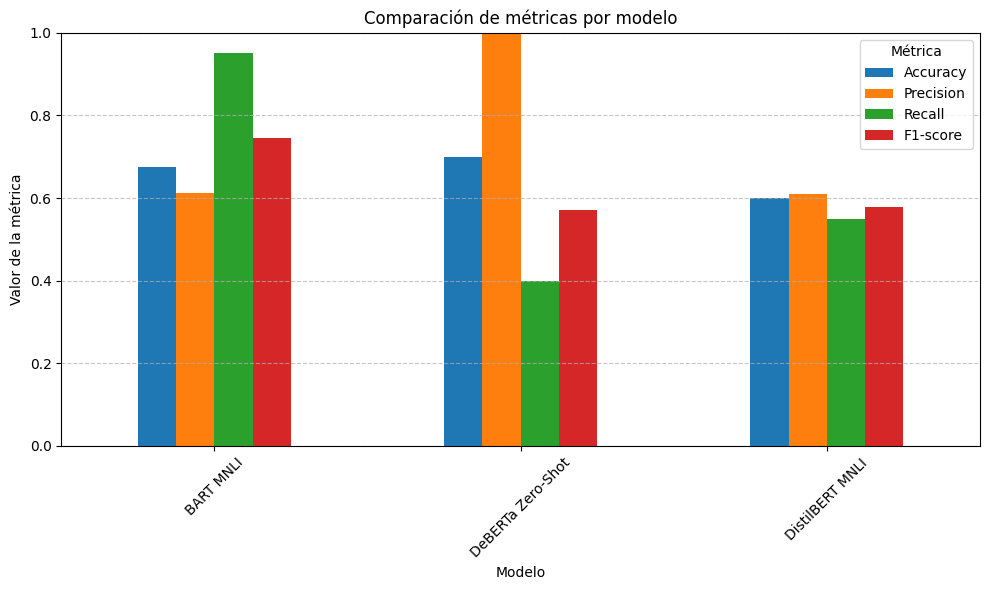

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

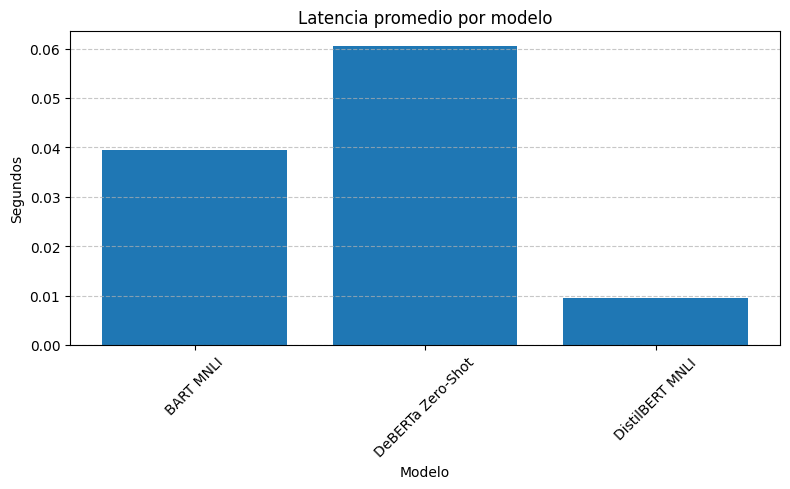

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

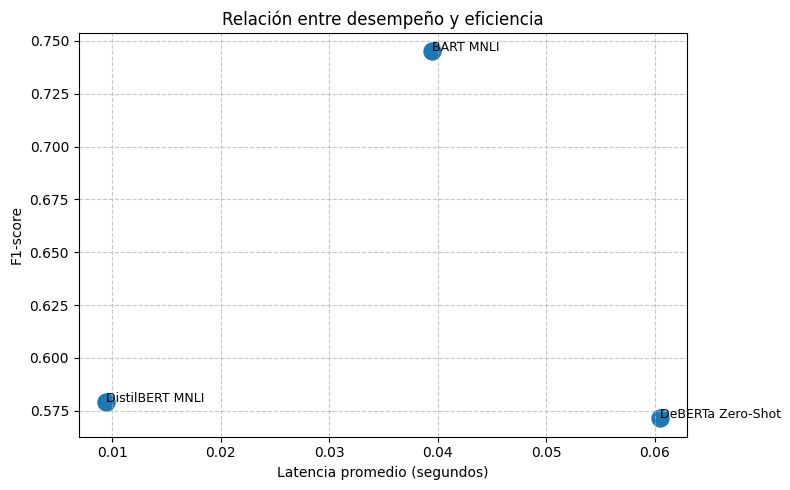

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos generados correctamente:
✔ resultados_comparacion_modelos.csv
✔ dataset_con_predicciones.csv
✔ grafica_metricas.png
✔ grafica_latencia.png
✔ grafica_tradeoff.png
✔ requirements.txt

Todos estos archivos en la actividad.

Conclusión final:

En esta actividad se implementaron y compararon tres modelos preentrenados de Hugging Face
para una tarea de clasificación de textos regulatorios relacionados con compliance.

Los modelos evaluados fueron:
- BART MNLI
- DeBERTa Zero-Shot
- DistilBERT MNLI

La comparación se realizó utilizando métricas estándar como accuracy, precision, recall,
F1-score y latencia promedio.

De acuerdo con los resultados obtenidos, el modelo con mejor desempeño general fue:

Modelo recomendado: BART MNLI
F1-score: 0.7451

Este modelo fue seleccionado porque presentó el mejor equilibrio entre precisión y capacidad
de detección de textos clasificados como riesgo, lo cual es importante en un contexto regulatorio.

Por otra parte, el modelo con mejor eficiencia e

In [8]:

# ACTIVIDAD 4
# Caso de uso: Clasificación de textos regulatorios
# Proyecto: Sistema Predictivo de Compliance para Labeling in Origin - Kerry

# PASO 1. INSTALACIÓN DE DEPENDENCIAS

!pip install transformers datasets evaluate accelerate scikit-learn pandas torch huggingface_hub -q


# PASO 2. CONFIGURACIÓN Y VERIFICACIÓN DE GPU

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo disponible:", device)

if device == "cuda":
    print("GPU utilizada:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU. El notebook correrá en CPU.")



# PASO 3. AUTENTICACIÓN EN HUGGING FACE HUB


from huggingface_hub import login

login()



# PASO 4. CARGA DEL DATASET


from google.colab import files

uploaded = files.upload()



# PASO 5. LECTURA Y REVISIÓN DEL DATASET


import pandas as pd

df = pd.read_csv("dataset_compliance_risk.csv")

print("Primeros registros del dataset:")
display(df.head())

print("\nInformación general del dataset:")
print(df.info())

print("\nDistribución de etiquetas:")
print(df["label"].value_counts())





# PASO 6. DEFINICIÓN DE LOS MODELOS A COMPARAR


models = {
    "BART MNLI": "facebook/bart-large-mnli",
    "DeBERTa Zero-Shot": "MoritzLaurer/deberta-v3-xsmall-zeroshot-v1.1-all-33",
    "DistilBERT MNLI": "typeform/distilbert-base-uncased-mnli"
}

candidate_labels = ["risk", "no_risk"]

print("Modelos seleccionados para la comparación:")
for name, model_id in models.items():
    print(f"{name}: {model_id}")



# PASO 7. IMPORTACIÓN DE LIBRERÍAS PARA INFERENCIA Y MÉTRICAS


from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import pandas as pd



# PASO 8. PIPELINE DE INFERENCIA, CÁLCULO DE MÉTRICAS Y LATENCIA


results = []
all_predictions = {}

for model_name, model_id in models.items():
    print("\n========================================")
    print(f"Evaluando modelo: {model_name}")
    print("========================================")

    classifier = pipeline(
        "zero-shot-classification",
        model=model_id,
        device=0 if device == "cuda" else -1
    )

    predictions = []
    latencies = []

    for text in df["text"]:
        start_time = time.time()
        output = classifier(text, candidate_labels)
        end_time = time.time()

        predicted_label = output["labels"][0]
        predictions.append(predicted_label)
        latencies.append(end_time - start_time)

    y_true = df["label"]
    y_pred = predictions

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="risk", zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label="risk", zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label="risk", zero_division=0)
    avg_latency = sum(latencies) / len(latencies)

    results.append({
        "Modelo": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Latencia promedio (segundos)": avg_latency
    })

    all_predictions[model_name] = predictions

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Latencia promedio: {avg_latency:.4f} segundos")



# PASO 9. TABLA COMPARATIVA DE RESULTADOS


results_df = pd.DataFrame(results)

print("Tabla comparativa de modelos:")
display(results_df)


# PASO 9.1 GRÁFICA COMPARATIVA DE MÉTRICAS

import matplotlib.pyplot as plt
from google.colab import files

metrics_df = results_df.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score"]]

metrics_df.plot(kind="bar", figsize=(10,6))

plt.title("Comparación de métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(title="Métrica")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig("grafica_metricas.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("grafica_metricas.png")



# PASO 9.2 GRÁFICA DE LATENCIA


plt.figure(figsize=(8,5))

plt.bar(
    results_df["Modelo"],
    results_df["Latencia promedio (segundos)"]
)

plt.title("Latencia promedio por modelo")
plt.xlabel("Modelo")
plt.ylabel("Segundos")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig("grafica_latencia.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("grafica_latencia.png")



# PASO 9.3 TRADE-OFF F1-SCORE VS LATENCIA

plt.figure(figsize=(8,5))

plt.scatter(
    results_df["Latencia promedio (segundos)"],
    results_df["F1-score"],
    s=150
)

for i, row in results_df.iterrows():
    plt.text(
        row["Latencia promedio (segundos)"],
        row["F1-score"],
        row["Modelo"],
        fontsize=9
    )

plt.title("Relación entre desempeño y eficiencia")
plt.xlabel("Latencia promedio (segundos)")
plt.ylabel("F1-score")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig("grafica_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("grafica_tradeoff.png")


# PASO 10 EXPORTAR RESULTADOS


results_df.to_csv(
    "resultados_comparacion_modelos.csv",
    index=False
)

df_results.to_csv(
    "dataset_con_predicciones.csv",
    index=False
)

files.download("resultados_comparacion_modelos.csv")
files.download("dataset_con_predicciones.csv")



# PASO 11 CREAR REQUIREMENTS.TXT


requirements = """
transformers
datasets
evaluate
accelerate
torch
pandas
scikit-learn
matplotlib
huggingface_hub
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

files.download("requirements.txt")



# PASO 12 RESUMEN FINAL


print("Archivos generados correctamente:")
print("✔ resultados_comparacion_modelos.csv")
print("✔ dataset_con_predicciones.csv")
print("✔ grafica_metricas.png")
print("✔ grafica_latencia.png")
print("✔ grafica_tradeoff.png")
print("✔ requirements.txt")

print("\nTodos estos archivos en la actividad.")


# ============================================================
# PASO 13. CONCLUSIÓN FINAL DEL NOTEBOOK
# ============================================================

best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]
fastest_model = results_df.sort_values(by="Latencia promedio (segundos)", ascending=True).iloc[0]

print("""
Conclusión final:

En esta actividad se implementaron y compararon tres modelos preentrenados de Hugging Face
para una tarea de clasificación de textos regulatorios relacionados con compliance.

Los modelos evaluados fueron:
- BART MNLI
- DeBERTa Zero-Shot
- DistilBERT MNLI

La comparación se realizó utilizando métricas estándar como accuracy, precision, recall,
F1-score y latencia promedio.

De acuerdo con los resultados obtenidos, el modelo con mejor desempeño general fue:
""")

print(f"Modelo recomendado: {best_model['Modelo']}")
print(f"F1-score: {best_model['F1-score']:.4f}")

print("""
Este modelo fue seleccionado porque presentó el mejor equilibrio entre precisión y capacidad
de detección de textos clasificados como riesgo, lo cual es importante en un contexto regulatorio.

Por otra parte, el modelo con mejor eficiencia en tiempo de respuesta fue:
""")

print(f"Modelo más rápido: {fastest_model['Modelo']}")
print(f"Latencia promedio: {fastest_model['Latencia promedio (segundos)']:.4f} segundos")

print("""
En conclusión, BART MNLI representa la opción más adecuada para este prototipo, ya que en procesos
de compliance es preferible detectar la mayor cantidad posible de riesgos, aunque el tiempo de respuesta
sea ligeramente mayor. Sin embargo, DistilBERT MNLI podría considerarse en escenarios donde la velocidad
sea más importante que la precisión del análisis.
""")